# Sentiment Analysis Methods

This notebook documents the sentiment analysis pipeline for TED talk transcripts and covers a change in approach that happened midway through the project.

## First approach summarize then score

Most sentiment models have a 512 token limit since many were trained on tweets or other short texts, which is nowhere near enough for a full TED talk transcript. The first workaround was to run each transcript through a summarizer first, then pass the summary to the sentiment model.

This technically worked but had two problems. First, it was about 10x slower than just running sentiment directly, the summarization step is expensive and it sits in front of every single talk. Second, and more importantly, you end up with one sentiment score per talk. A summary collapses the whole thing into a single output so there's no way to tell how the sentiment moves across the talk, which would be interesting to find out whether it starts heavy and lightens up, or builds to something, or drags at the end.

## Setup

We only need 5 talks here since this notebook is about benchmarking and exploring the methods, not running the full dataset.

We use `cardiffnlp/twitter-roberta-base-sentiment` as the sentiment model. It outputs three labels: `LABEL_0` (negative), `LABEL_1` (neutral), `LABEL_2` (positive). `parse_res` maps those back to readable labels and `ml_polarity` converts the result to a signed score.

In [2]:
summarizer = pipeline("summarization", model="pszemraj/led-base-book-summary")
sentiment  = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment")

map_emotion = {"LABEL_0": "NEG", "LABEL_1": "NEU", "LABEL_2": "POS"}


def parse_res(output):
    return {"label": map_emotion[output[0]["label"]], "score": output[0]["score"]}


def ml_polarity(output):
    parsed = parse_res(output)
    if parsed["label"] == "NEG":
        return -parsed["score"]
    if parsed["label"] == "NEU":
        return 0
    return parsed["score"]

C:\Users\elzes\anaconda3\envs\project_sentiment\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\elzes\anaconda3\envs\project_sentiment\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Quick sanity check to make sure the labels and polarity conversion are working as expected.

In [3]:
print(parse_res(sentiment("I am happy right now")))
print(parse_res(sentiment("I am sad right now")))
print(parse_res(sentiment("the car drove by")))

{'label': 'POS', 'score': 0.9842681288719177}
{'label': 'NEG', 'score': 0.9484936594963074}
{'label': 'NEU', 'score': 0.690041720867157}


### Benchmarking the summarize approach

Running the full summarize then score pipeline on the 5 sample talks to get a time reading.

In [4]:
sample = df["transcript"].iloc[:5].tolist()

start = time.time()
for text in sample:
    summary = summarizer(text, max_length=500)
    print(parse_res(sentiment(summary[0]["summary_text"])))
print(f"summarize + sentiment: {time.time() - start:.1f}s for {len(sample)} talks")

{'label': 'NEU', 'score': 0.4880943298339844}
{'label': 'POS', 'score': 0.9138175249099731}
{'label': 'NEG', 'score': 0.7608746886253357}
{'label': 'NEU', 'score': 0.5003383159637451}
{'label': 'NEU', 'score': 0.5243414044380188}
summarize + sentiment: 74.9s for 5 talks


## New approach -- chunking

Instead of summarizing, we split each transcript into fixed-size chunks and run the sentiment model on each chunk separately. This stays within the token limit without needing a summarizer in front of it, so it's much faster.

The bigger benefit is that chunking gives a sentiment curve over time. Each chunk maps to a rough position in the talk, so we can actually see where things get exciting, where the audience is probably engaged, and where the energy dips. That's a lot more useful than a single score for the whole talk.

### Benchmarking the chunking approach

Same 5 talks, but this time we chunk and score directly. The time difference compared to the summarize approach is the main thing to look at here.

In [5]:
def chunk_transcript(text, size=50, overlap=5):
    words = text.split()
    if len(words) < size:
        return [text]
    chunks = []
    for i in range(overlap, len(words), size):
        chunk = " ".join(words[i-overlap:i+size])
        if len(chunk.split()) >= size:
            chunks.append(chunk)
    return chunks


start = time.time()
for text in sample:
    for chunk in chunk_transcript(text):
        print(parse_res(sentiment(chunk)))
print(f"chunked sentiment: {time.time() - start:.1f}s for {len(sample)} talks")

{'label': 'POS', 'score': 0.9794244766235352}
{'label': 'NEG', 'score': 0.5920109152793884}
{'label': 'POS', 'score': 0.626667320728302}
{'label': 'NEG', 'score': 0.4995323717594147}
{'label': 'NEU', 'score': 0.6107698678970337}
{'label': 'NEG', 'score': 0.46248915791511536}
{'label': 'NEU', 'score': 0.5849049687385559}
{'label': 'POS', 'score': 0.5676816701889038}
{'label': 'POS', 'score': 0.6236416101455688}
{'label': 'POS', 'score': 0.9737293124198914}
{'label': 'POS', 'score': 0.5056155920028687}
{'label': 'NEU', 'score': 0.6571742296218872}
{'label': 'POS', 'score': 0.7971053719520569}
{'label': 'NEU', 'score': 0.6692636013031006}
{'label': 'NEU', 'score': 0.6635902523994446}
{'label': 'NEU', 'score': 0.5176684856414795}
{'label': 'NEG', 'score': 0.4954566955566406}
{'label': 'NEG', 'score': 0.9189577102661133}
{'label': 'NEU', 'score': 0.5951091647148132}
{'label': 'NEU', 'score': 0.7132860422134399}
{'label': 'NEU', 'score': 0.5540961027145386}
{'label': 'NEG', 'score': 0.671360

### Building the sentiment curve

Now we run chunking across all talks and collect the results into a dataframe. Each row is one chunk, with its position through the talk (0.0 to 1.0) and signed sentiment score. With out func we will change it into a number between -1 and 1

In [6]:
rows = []
for idx, row in df.iterrows():
    chunks = chunk_transcript(row["transcript"])
    for chunk_idx, chunk in enumerate(chunks):
        result = sentiment(chunk)
        rows.append({
            "talk_idx": idx,
            "title":    row["title"],
            "chunk":    chunk_idx,
            "position": chunk_idx / max(len(chunks) - 1, 1),
            "label":    parse_res(result)["label"],
            "score":    ml_polarity(result),
        })

sentiment_df = pd.DataFrame(rows)
print(sentiment_df.head(10))

   talk_idx                        title  chunk  position label     score
0         0  Do schools kill creativity?      0  0.000000   POS  0.979424
1         0  Do schools kill creativity?      1  0.016667   NEG -0.592011
2         0  Do schools kill creativity?      2  0.033333   POS  0.626667
3         0  Do schools kill creativity?      3  0.050000   NEG -0.499532
4         0  Do schools kill creativity?      4  0.066667   NEU  0.000000
5         0  Do schools kill creativity?      5  0.083333   NEG -0.462489
6         0  Do schools kill creativity?      6  0.100000   NEU  0.000000
7         0  Do schools kill creativity?      7  0.116667   POS  0.567682
8         0  Do schools kill creativity?      8  0.133333   POS  0.623642
9         0  Do schools kill creativity?      9  0.150000   POS  0.973729


### Visualising the results

First a raw overlay of all talks, then a smoothed version using a gaussian filter to make the trends easier to read. Below that, individual bar charts for each talk so you can look at them one by one.

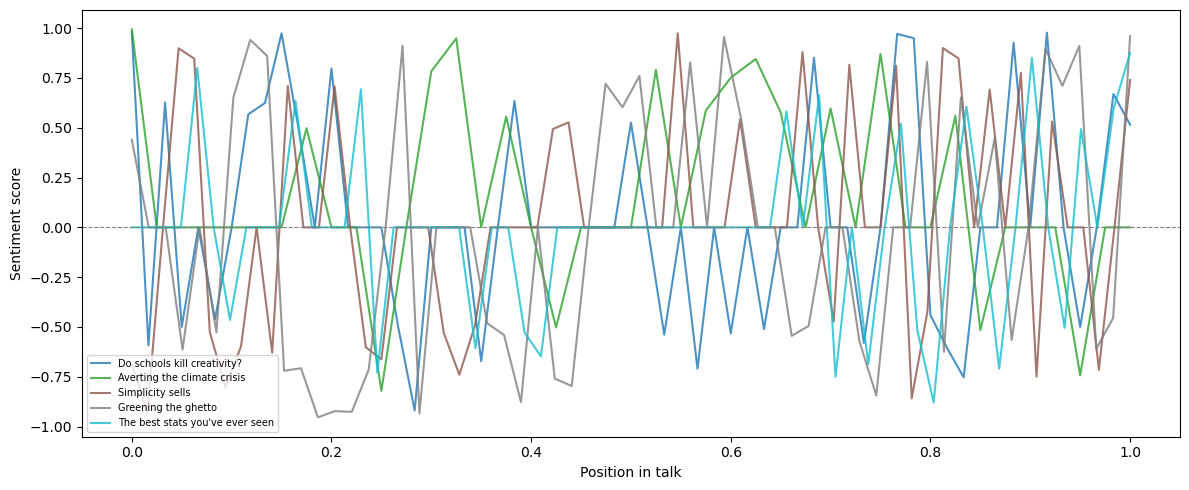

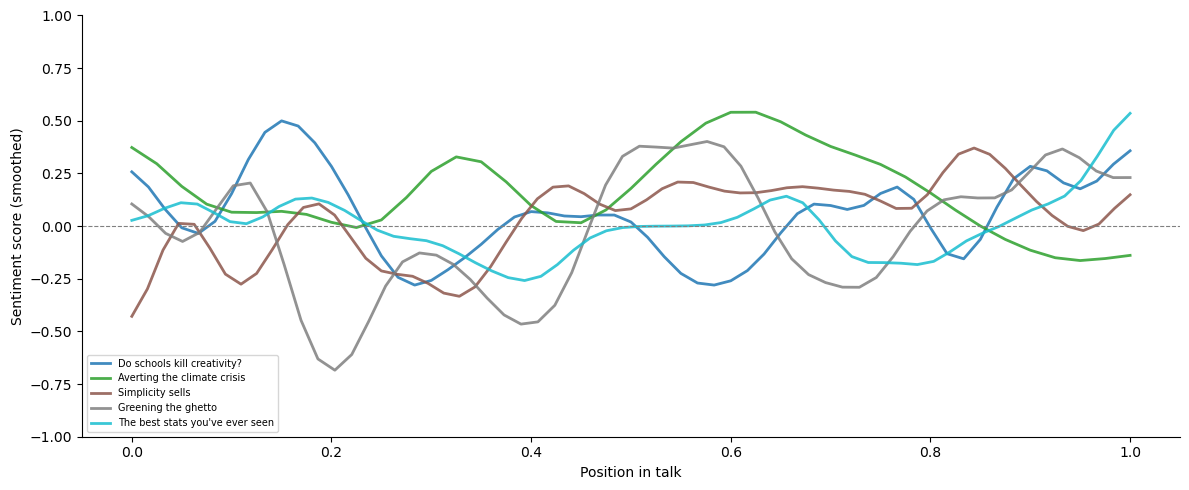

In [7]:
talks  = sentiment_df["talk_idx"].unique()
colors = cm.tab10(np.linspace(0, 1, len(talks)))

# Raw overlay
fig, ax = plt.subplots(figsize=(12, 5))
for color, idx in zip(colors, talks):
    d = sentiment_df[sentiment_df["talk_idx"] == idx]
    ax.plot(d["position"], d["score"], label=d["title"].iloc[0][:40], color=color, alpha=0.8)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Position in talk")
ax.set_ylabel("Sentiment score")
ax.legend(fontsize=7, loc="lower left")
plt.tight_layout()
plt.show()

# Smoothed overlay
fig, ax = plt.subplots(figsize=(12, 5))
for color, idx in zip(colors, talks):
    d        = sentiment_df[sentiment_df["talk_idx"] == idx].sort_values("chunk")
    smoothed = gaussian_filter1d(d["score"].values, sigma=2)
    ax.plot(d["position"].values, smoothed, label=d["title"].iloc[0][:40], color=color, linewidth=2, alpha=0.85)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Position in talk")
ax.set_ylabel("Sentiment score (smoothed)")
ax.set_ylim(-1, 1)
ax.legend(fontsize=7, loc="lower left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

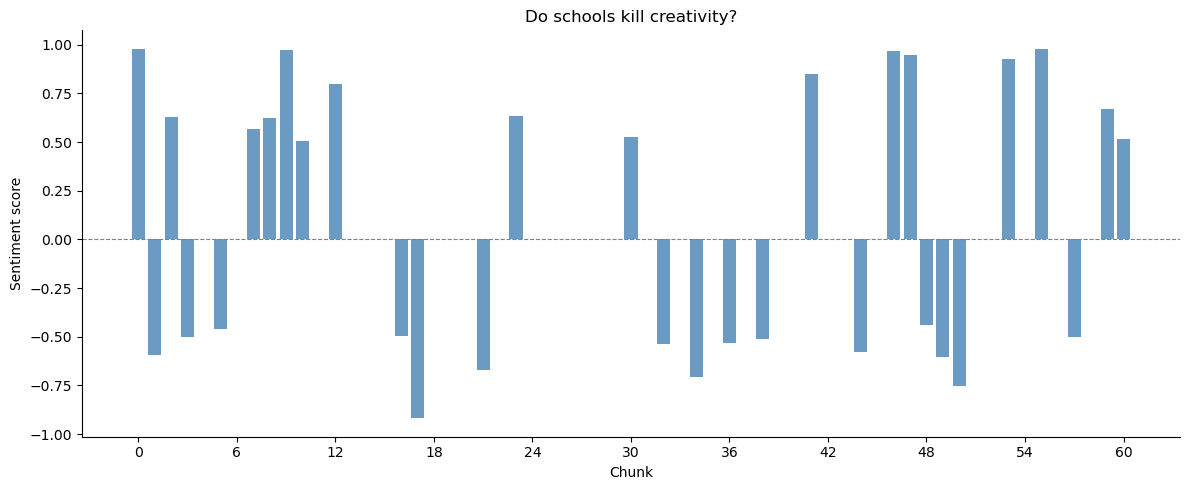

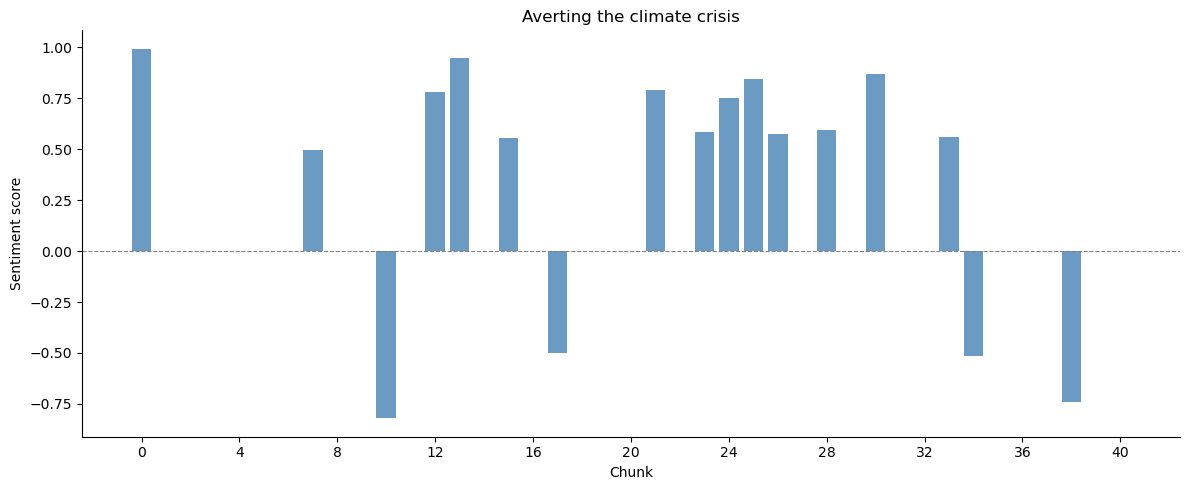

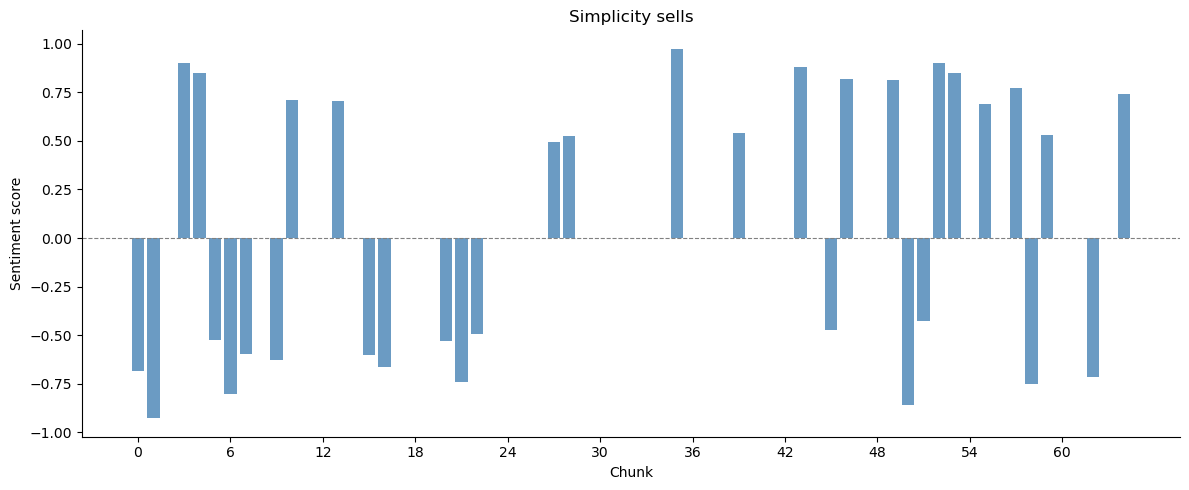

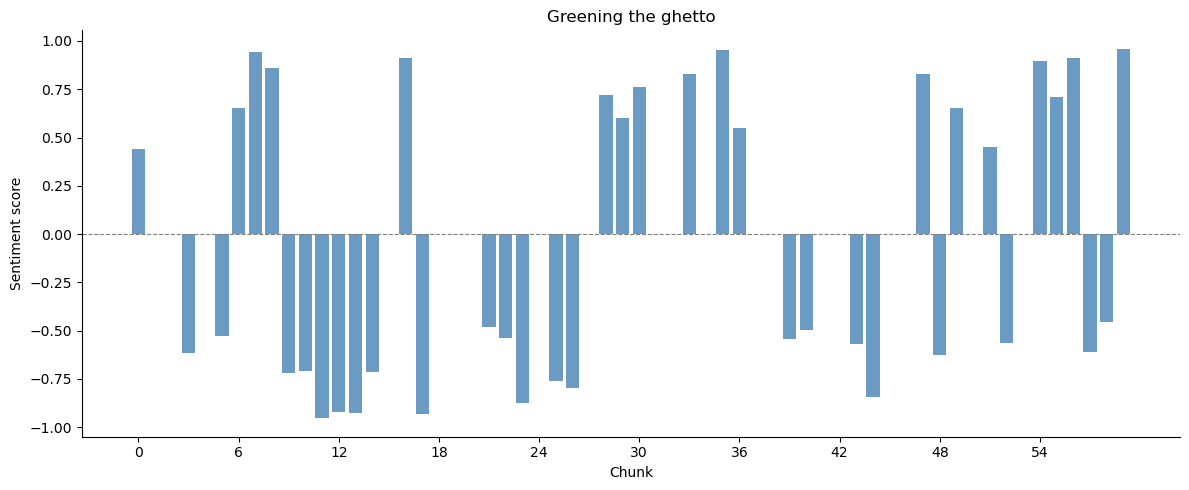

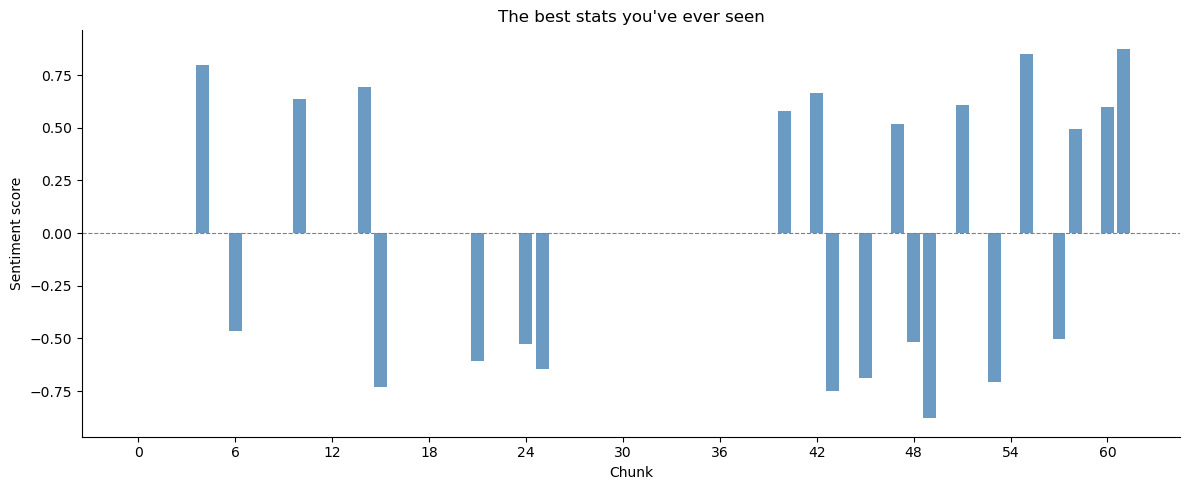

In [8]:
# Individual bar chart per talk
for idx in talks:
    d     = sentiment_df[sentiment_df["talk_idx"] == idx].copy()
    title = d["title"].iloc[0]
    x     = np.arange(len(d))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x, d["score"], color="steelblue", alpha=0.8, width=0.8)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Chunk")
    ax.set_ylabel("Sentiment score")
    ax.set_title(title[:60])
    ax.set_xticks(x[::max(1, len(x) // 10)])
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()